In [ ]:
#!pip install folium

In [ ]:
#!pip install contextily

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1mXQ4XkoD57eRPWV4XDSKD3BVX7DEXcl6')
df

,bus_code,trip_id,gps_datetime,location,dtd,corridor,longitude,latitude,speed,course,color
0,DMR 5049,5.112,2019-11-26 14:00:29,NaN,0.0,0,106.867523,-6.224230,0.0,208,MERAH KUNING
1,DMR 5049,5.112,2019-11-26 14:00:54,NaN,0.0,0,106.867523,-6.224230,0.0,208,MERAH KUNING
2,DMR 5049,5.112,2019-11-26 14:01:29,NaN,0.0,0,106.867523,-6.224230,0.0,208,MERAH KUNING
3,DMR 5049,5.112,2019-11-26 14:01:59,NaN,0.0,0,106.867523,-6.224230,0.0,208,MERAH KUNING
4,DMR 5049,5.112,2019-11-26 14:02:29,NaN,0.0,0,106.867523,-6.224230,0.0,208,MERAH KUNING
...,...,...,...,...,...,...,...,...,...,...,...
775453,TSW 100,8.D001,2019-11-26 17:57:56,NaN,0.0,8D,106.741697,-6.220093,0.1,67,ORANGE KOMBINASI
775454,TSW 100,8.D001,2019-11-26 17:58:26,NaN,0.0,8D,106.741697,-6.220093,0.0,67,ORANGE KOMBINASI
775455,TSW 100,8.D001,2019-11-26 17:58:53,NaN,0.0,8D,106.741697,-6.220093,0.0,67,ORANGE KOMBINASI
775456,TSW 100,8.D001,2019-11-26 17:59:25,NaN,0.0,8D,106.741655,-6.220058,0.0,67,ORANGE KOMBINASI


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775458 entries, 0 to 775457
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   bus_code      775458 non-null  object 
 1   trip_id       773791 non-null  object 
 2   gps_datetime  775458 non-null  object 
 3   location      234477 non-null  object 
 4   dtd           775458 non-null  float64
 5   corridor      775458 non-null  object 
 6   longitude     775458 non-null  float64
 7   latitude      775458 non-null  float64
 8   speed         775458 non-null  float64
 9   course        775458 non-null  int64  
 10  color         663910 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 65.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(48230)

In [ ]:
df.isnull().sum()

,0
bus_code,0
trip_id,1667
gps_datetime,0
location,540981
dtd,0
corridor,0
longitude,0
latitude,0
speed,0
course,0


In [ ]:
df = df.drop_duplicates()

df['trip_id'] = df['trip_id'].fillna("Unknown")
df['color'] = df['color'].fillna("Unknown")
df = df.drop(columns=['location'])

# karena ram tidak kuat
df['latitude'] = df['latitude'].astype('float32')
df['longitude'] = df['longitude'].astype('float32')

df.info()


/tmp/ipython-input-1257775891.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trip_id'] = df['trip_id'].fillna("Unknown")
/tmp/ipython-input-1257775891.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['color'] = df['color'].fillna("Unknown")


<class 'pandas.core.frame.DataFrame'>
Index: 727228 entries, 0 to 775457
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   bus_code      727228 non-null  object 
 1   trip_id       727228 non-null  object 
 2   gps_datetime  727228 non-null  object 
 3   dtd           727228 non-null  float64
 4   corridor      727228 non-null  object 
 5   longitude     727228 non-null  float32
 6   latitude      727228 non-null  float32
 7   speed         727228 non-null  float64
 8   course        727228 non-null  int64  
 9   color         727228 non-null  object 
dtypes: float32(2), float64(2), int64(1), object(5)
memory usage: 55.5+ MB


In [ ]:
peta_jabodetabek = folium.Map(location=[-6.2, 106.8], zoom_start=11)

df_jabo = df[
    (df['latitude'] >= -6.8) & (df['latitude'] <= -5.7) &
    (df['longitude'] >= 106.5) & (df['longitude'] <= 107.1)
]

data_heatmap = df_jabo[['latitude', 'longitude']].values.tolist()

HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta_jabodetabek)

peta_jabodetabek

Output hidden; open in https://colab.research.google.com to view.

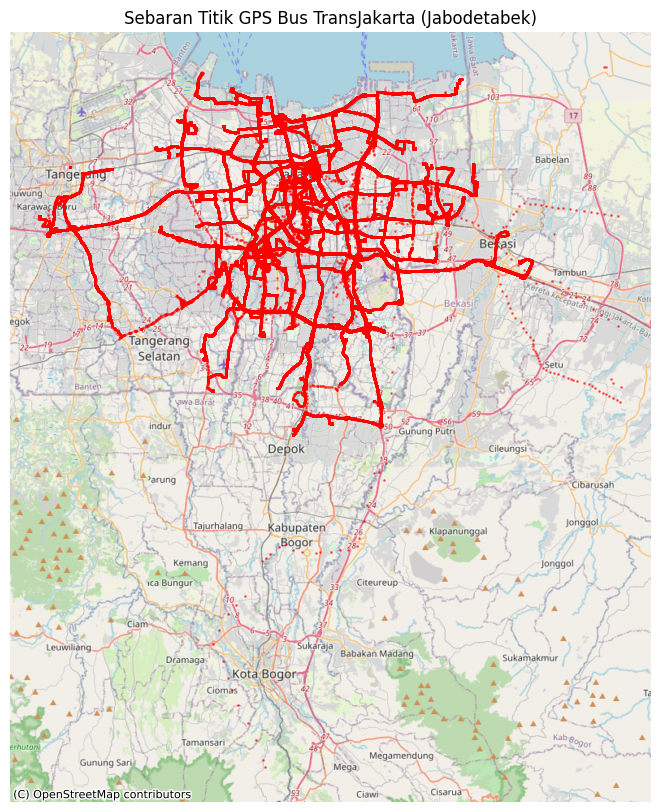

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx

# Filter Jabodetabek agar peta fokus
df_jabo = df[
    (df['latitude'] >= -6.8) & (df['latitude'] <= -5.7) &
    (df['longitude'] >= 106.5) & (df['longitude'] <= 107.1)
]

# Buat geometri point dari lat & lon
geometry = [Point(xy) for xy in zip(df_jabo['longitude'], df_jabo['latitude'])]
gdf = gpd.GeoDataFrame(df_jabo, geometry=geometry, crs="EPSG:4326")

# Konversi ke Web Mercator agar cocok dengan basemap
gdf = gdf.to_crs(epsg=3857)

# Plot peta titik GPS
fig, ax = plt.subplots(figsize=(10,10))
gdf.plot(ax=ax, markersize=1, alpha=0.5, color='red')

# Tambah basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Sebaran Titik GPS Bus TransJakarta (Jabodetabek)")
ax.set_axis_off()
plt.show()


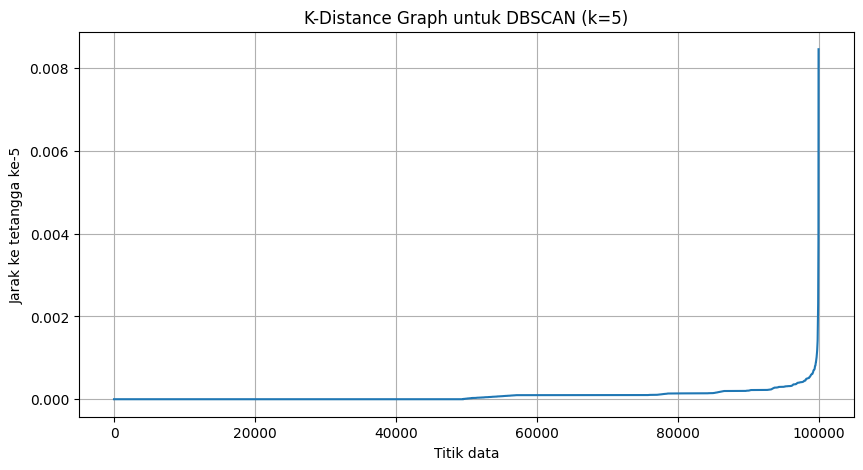

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# DBSCAN SAMPLE: untuk menghitung Silhouette Score tanpa membebani RAM
coords_sample = df_jabo[['latitude','longitude']].values[:100000]

# Tentukan k = min_samples (5)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(coords_sample)
distances, indices = neighbors_fit.kneighbors(coords_sample)

# Sort distance ascending buat lihat titik belokan (elbow)
distances = np.sort(distances[:, 4])  # index 4 karena k=5

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("K-Distance Graph untuk DBSCAN (k=5)")
plt.xlabel("Titik data")
plt.ylabel("Jarak ke tetangga ke-5")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Model DBSCAN SAMPLE
dbscan_sample = DBSCAN(eps=0.0013, min_samples=5)
labels_sample = dbscan_sample.fit_predict(coords_sample)

# Hitung Silhouette Score (cluster valid minimal 2 cluster)
unique_labels = set(labels_sample)
if len(unique_labels) > 1:
    sil_score = silhouette_score(coords_sample, labels_sample)
    print("Silhouette Score:", sil_score)
else:
    print("Silhouette Score tidak dapat dihitung (hanya 1 cluster)")


Silhouette Score: -0.38554737


/tmp/ipython-input-3770611531.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(unique_labels))


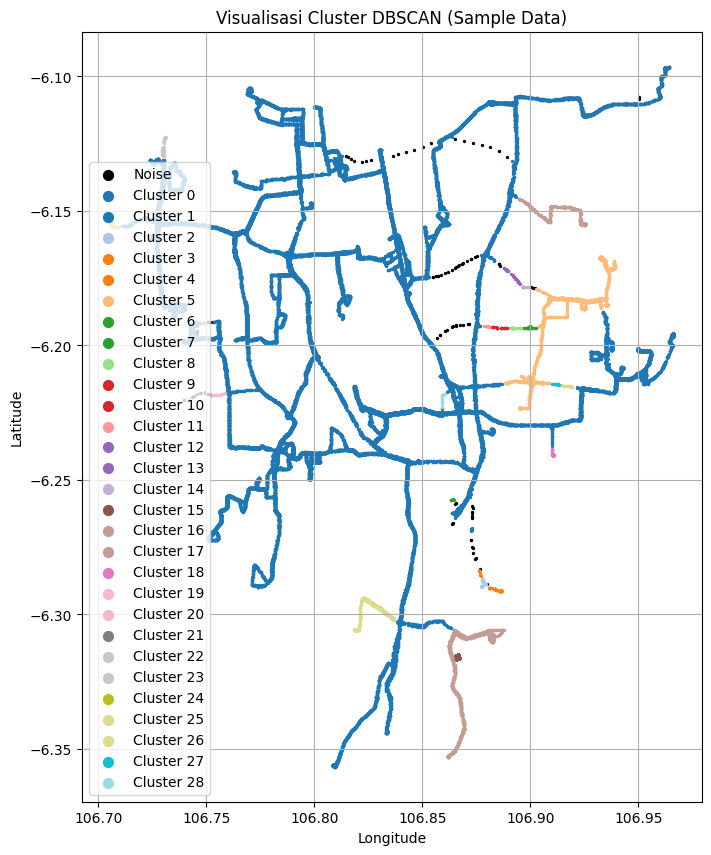

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Warna cluster (noise = -1 → warna hitam)
unique_labels = np.unique(labels_sample)
colors = plt.cm.get_cmap("tab20", len(unique_labels))

plt.figure(figsize=(8, 10))
for label in unique_labels:
    mask = labels_sample == label
    if label == -1:
        plt.scatter(coords_sample[mask, 1], coords_sample[mask, 0], s=2, c='black', label='Noise')
    else:
        plt.scatter(coords_sample[mask, 1], coords_sample[mask, 0], s=2, c=[colors(label)], label=f'Cluster {label}')

plt.title("Visualisasi Cluster DBSCAN (Sample Data)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend(markerscale=5)
plt.show()


In [ ]:
import folium
from folium.plugins import MarkerCluster

# Map Jabodetabek
peta_cluster = folium.Map(location=[-6.2, 106.8], zoom_start=11)

# Warna untuk cluster
def get_color(label):
    if label == -1:
        return 'black'  # noise
    return f'#{hex((label * 1234567) % 0xFFFFFF)[2:].zfill(6)}'

# Tambah marker cluster
marker_cluster = MarkerCluster().add_to(peta_cluster)

for lat, lon, label in zip(df_jabo['latitude'][:100000], df_jabo['longitude'][:100000], labels_sample):
    folium.CircleMarker(
        location=[lat, lon],
        radius=1.5,
        color=get_color(label),
        fill=True,
        fill_opacity=0.9,
    ).add_to(marker_cluster)

peta_cluster


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Hasil final berdasarkan sample, karena keterbatasan RAM

unique_clusters = set(labels_sample)
if -1 in unique_clusters:
    unique_clusters.remove(-1)

jumlah_cluster = len(unique_clusters)
jumlah_noise = list(labels_sample).count(-1)
persen_noise = (jumlah_noise / len(labels_sample)) * 100

print("Jumlah cluster valid:", jumlah_cluster)
print("Jumlah noise:", jumlah_noise)
print(f"Persentase noise: {persen_noise:.2f}%")


Jumlah cluster valid: 29
Jumlah noise: 105
Persentase noise: 0.10%
